In [1]:
import numpy as np
import pandas as pd
import json
from collections import Counter
from pathlib import Path

# ── Bloco 3 · UPGMA e PAM para k = 1 … 10, as três curvas e o dendrograma ──
import subprocess
from math import comb
from scipy.cluster.hierarchy import linkage, cophenet, dendrogram
from scipy.spatial.distance import squareform
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.colors import LinearSegmentedColormap

In [2]:
# 1a. Os cinco caracteres, com resíduo = carácter ausente (None). Os 6 com resíduo de FUNÇÃO
#     vão direto para a família de resíduos e ficam fora do agrupamento (regra D3).
EIXOS = ['funcao', 'motor', 'regime', 'surrogate', 'medicao']
PESOS = {'funcao': 0.40, 'motor': 0.30, 'regime': 0.10, 'surrogate': 0.10, 'medicao': 0.10} # D1 (rank-sum)


########## Árvores Funcao Incerteza
ATITUDE  = {'OV':'oportunidade',
            'OM':'oportunidade',
            'OL':'oportunidade',
            'AV':'ameaça',
            'AM':'ameaça',
            'AR':'ameaça'}

OBJETO   = {'OV':'valor',     'AV':'valor',
            'OM':'modelo',    'AM':'modelo',
            'OL':'próprio-OL','AR':'próprio-AR'}


########## Árvores Motor Otimizacao
PARADIGMA= {'EA-Dominância':         'EA',
            'EA-Decomposição':       'EA',
            'EA-Indicador':          'EA',
            'BO-Melhoria-de-Pareto': 'BO',
            'BO-Decomposição':       'BO',
            'BO-Hipervolume':        'BO',
            'BO-Especiais':          'BO'}

PRINCIPIO= { # par espelhado 1
            'EA-Dominância'         : 'dominância',
            'BO-Melhoria-de-Pareto' : 'dominância',
             # par espelhado 2
            'EA-Decomposição'       : 'decomposição',
            'BO-Decomposição'       : 'decomposição',
             # par espelhado 3
            'EA-Indicador'          : 'indicador',
            'BO-Hipervolume'        : 'indicador',     
             # sem espelho
            'BO-Especiais'          : 'especiais'}


########## Árvore Surrogate
TIPO_SUR = {'GP':'regressor',
            'RG':'regressor',
            'NN':'regressor',
            'CL':'classificador'}


########## Árvore Medicao Incerteza
FONTE4   = {'VA': 'analítica', 
            'VN': 'nativa', 
            'DE': 'exógena', 
            'EE': 'exógena', 
            'DG': 'exógena'}

In [3]:
########### Função de visualização
sns.set_theme(style="white", context="notebook")
plt.rcParams.update({"figure.dpi": 110, "savefig.dpi": 150, "axes.titleweight": "bold",
                     "axes.titlesize": 13, "font.size": 11, "axes.titlepad": 12,
                     "axes.edgecolor": "#cfcfcf", "axes.linewidth": 0.6})
GREENS = LinearSegmentedColormap.from_list(
    "GreensTrunc", plt.get_cmap("Greens")(np.linspace(0.12, 0.95, 256)))
BASE_FS = 9

def _ordem(d, col):
    """Categorias por frequência decrescente, com o resíduo sempre no fim."""
    cats = list(d[col].value_counts().index)
    res = [c for c in cats if str(c).lower().startswith("res")]
    return [c for c in cats if c not in res] + res

def _trim(s, n=24):
    s = str(s)
    return s if len(s) <= n else s[:n-1] + "…"

def heatmap_2d(df, linhas, colunas, vmax=50, figsize=(7.0, 6.0), rot_x=35,
               escala_fonte=1.3, titulo=None, salvar_em=None,
               ordem_linhas=None, ordem_colunas=None):
    """
    linhas  : coluna da base no eixo Y
    colunas : coluna da base no eixo X
    vmax    : teto da escala de cor (None = máximo observado)
    Devolve a tabela de contingência.
    """
    d = df.copy()
    ct = (pd.crosstab(d[linhas], d[colunas])
            .reindex(index=ordem_linhas or _ordem(d, linhas),
                     columns=ordem_colunas or _ordem(d, colunas), fill_value=0).astype(int))

    fig, ax = plt.subplots(figsize=figsize)
    ax.set_facecolor("white")
    sns.heatmap(ct, ax=ax, cmap=GREENS, mask=(ct == 0),
                annot=ct.astype(str).where(ct > 0, ""), fmt="",
                linewidths=0, cbar=False, vmax=vmax,
                xticklabels=[_trim(c) for c in ct.columns],
                yticklabels=[_trim(i) for i in ct.index],
                annot_kws={"fontsize": BASE_FS * 1.65})

    # célula de valor 1 fica 50% mais clara, para não competir com as demais
    mesh = ax.collections[0]
    fc = np.array(mesh.get_facecolors(), dtype=float)
    for k, v in enumerate(ct.values.ravel()):
        if v == 1:
            r, g, b, a = fc[k]
            fc[k] = [r + (1-r)*.5, g + (1-g)*.5, b + (1-b)*.5, a]
    mesh.set_facecolors(fc); mesh.set_array(None)

    ax.grid(False); ax.set_xlabel(""); ax.set_ylabel("")
    if titulo: ax.set_title(titulo)
    plt.setp(ax.get_xticklabels(), rotation=rot_x, ha="right" if rot_x else "center")
    plt.setp(ax.get_yticklabels(), rotation=0)
    for t in [*ax.get_xticklabels(), *ax.get_yticklabels()]:
        t.set_fontsize(t.get_fontsize() * escala_fonte)

    fig.tight_layout()
    if salvar_em: fig.savefig(salvar_em, bbox_inches="tight")
    return ct

In [4]:
def caracter(v, eixo):
    x = v[eixo]
    return None if x.startswith('Res') else x

## Leitura e preparacao dos Dados

In [5]:
### Leitura de dados
MESTRADO = Path('/Users/gmello/Documents/python_repos/mestrado')
base = json.load(open(MESTRADO / 'dissertacao/SPEC/bases/base127.json', encoding='utf-8'))
ids = sorted(base)

### Convete em dataframe
df = pd.DataFrame({e: [caracter(base[i], e) for i in ids] for e in EIXOS}, index=ids)
df.insert(0, 'acronimo', [base[i]['acronimo'][:24] for i in ids])
df = df.reset_index().rename(columns={'index': 'id'})

print(df.shape)
df.head()

(127, 7)


,id,acronimo,funcao,motor,regime,surrogate,medicao
0,b1,ParEGO,OV,BO-Decomposição,online,GP,VA
1,b13,AdaMoR-DDMOEA,AM,EA-Decomposição,offline,NN,EE
2,b14,SA²-MOEA,OM,EA-Dominância,online,RG,DE
3,b15,U-RankMOEA,OV,BO-Especiais,online,GP,DE
4,b2,MOEA/D-EGO,OV,BO-Decomposição,online,GP,VA


In [6]:
### Calcula Macro Agrupamentos
df['atitude_funcao']   = df['funcao'].map(ATITUDE)     # oportunidade · ameaça
df['objeto_funcao']    = df['funcao'].map(OBJETO)      # valor · modelo · próprio-OL · próprio-AR
df['paradigma_motor']  = df['motor'].map(PARADIGMA)    # BO · EA
df['principio_motor']  = df['motor'].map(PRINCIPIO)    # dominância · decomposição · indicador · especiais
df['tipo_surrogate']   = df['surrogate'].map(TIPO_SUR) # regressor · classificador
df['fonte_incerteza4'] = df['medicao'].map(FONTE4)     # os quatro níveis da tabela do D9 (NaN = resíduo de medição)
df['fonte_incerteza']  = np.where(df['medicao'].isna(),  'fabricada', # os dois níveis do Bloco 4: analítica × fabricada
                         np.where(df['medicao'] == 'VA', 'analítica', 'fabricada'))

print(df.shape)
df.head()

(127, 14)


,id,acronimo,funcao,motor,regime,surrogate,medicao,atitude_funcao,objeto_funcao,paradigma_motor,principio_motor,tipo_surrogate,fonte_incerteza4,fonte_incerteza
0,b1,ParEGO,OV,BO-Decomposição,online,GP,VA,oportunidade,valor,BO,decomposição,regressor,analítica,analítica
1,b13,AdaMoR-DDMOEA,AM,EA-Decomposição,offline,NN,EE,ameaça,modelo,EA,decomposição,regressor,exógena,fabricada
2,b14,SA²-MOEA,OM,EA-Dominância,online,RG,DE,oportunidade,modelo,EA,dominância,regressor,exógena,fabricada
3,b15,U-RankMOEA,OV,BO-Especiais,online,GP,DE,oportunidade,valor,BO,especiais,regressor,exógena,fabricada
4,b2,MOEA/D-EGO,OV,BO-Decomposição,online,GP,VA,oportunidade,valor,BO,decomposição,regressor,analítica,analítica


## [F1] Familias teóricas / naive

In [7]:
keys_teoricas = ['atitude_funcao', 'paradigma_motor', 'fonte_incerteza']

dp_familias_teoricas = df.groupby(keys_teoricas, dropna=True).size().sort_values(ascending=False).reset_index(name = 'algoritmos')
dp_familias_teoricas['familia_teorica'] = (dp_familias_teoricas['paradigma_motor'] + '_' + 
                                           dp_familias_teoricas['atitude_funcao'] + '_' + 
                                           dp_familias_teoricas['fonte_incerteza'])
dp_familias_teoricas

,atitude_funcao,paradigma_motor,fonte_incerteza,algoritmos,familia_teorica
0,oportunidade,BO,analítica,59,BO_oportunidade_analítica
1,ameaça,EA,fabricada,13,EA_ameaça_fabricada
2,oportunidade,EA,analítica,13,EA_oportunidade_analítica
3,ameaça,EA,analítica,11,EA_ameaça_analítica
4,oportunidade,BO,fabricada,8,BO_oportunidade_fabricada
5,oportunidade,EA,fabricada,7,EA_oportunidade_fabricada
6,ameaça,BO,analítica,4,BO_ameaça_analítica


In [8]:
df2 = df.merge(dp_familias_teoricas[keys_teoricas + ['familia_teorica']], 
               on = keys_teoricas, 
               how = 'left')

print(df2['familia_teorica'].isna().mean())

df2['familia_teorica'] = df2['familia_teorica'].fillna('residuo')
df2

0.09448818897637795


,id,acronimo,funcao,motor,regime,surrogate,medicao,atitude_funcao,objeto_funcao,paradigma_motor,principio_motor,tipo_surrogate,fonte_incerteza4,fonte_incerteza,familia_teorica
0,b1,ParEGO,OV,BO-Decomposição,online,GP,VA,oportunidade,valor,BO,decomposição,regressor,analítica,analítica,BO_oportunidade_analítica
1,b13,AdaMoR-DDMOEA,AM,EA-Decomposição,offline,NN,EE,ameaça,modelo,EA,decomposição,regressor,exógena,fabricada,EA_ameaça_fabricada
2,b14,SA²-MOEA,OM,EA-Dominância,online,RG,DE,oportunidade,modelo,EA,dominância,regressor,exógena,fabricada,EA_oportunidade_fabricada
3,b15,U-RankMOEA,OV,BO-Especiais,online,GP,DE,oportunidade,valor,BO,especiais,regressor,exógena,fabricada,BO_oportunidade_fabricada
4,b2,MOEA/D-EGO,OV,BO-Decomposição,online,GP,VA,oportunidade,valor,BO,decomposição,regressor,analítica,analítica,BO_oportunidade_analítica
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
122,o56,ε-PoHVI,OV,BO-Hipervolume,online,GP,VA,oportunidade,valor,BO,indicador,regressor,analítica,analítica,BO_oportunidade_analítica
123,o6,KEMOCO,OV,BO-Hipervolume,online,GP,VA,oportunidade,valor,BO,indicador,regressor,analítica,analítica,BO_oportunidade_analítica
124,pp6,AB-MOEA,AV,EA-Decomposição,online,GP,VA,ameaça,valor,EA,decomposição,regressor,analítica,analítica,EA_ameaça_analítica
125,wang4,SA-NSGA-II,AM,EA-Dominância,offline,None,EE,ameaça,modelo,EA,dominância,NaN,exógena,fabricada,EA_ameaça_fabricada


## [F2] Famílias agrupamento hierárquico

#### Funcoes para calculo de distancia entre 2 algoritmos no espaço de eixos taxonômicos

In [9]:
def d_ramo_classe(a, b, ramo, classe):
    """Regra comum a função e motor: 0 igual · 1/3 mesmo ramo · 2/3 ramos diferentes, classes espelhadas · 1 tudo diferente."""
    if a == b:                 return 0.0
    if ramo[a] == ramo[b]:     return 1/3
    if classe[a] == classe[b]: return 2/3
    return 1.0

def d_funcao(a, b):    return d_ramo_classe(a, b, ATITUDE, OBJETO)
def d_motor(a, b):     return d_ramo_classe(a, b, PARADIGMA, PRINCIPIO)
def d_surrogate(a, b):
    if a == b: return 0.0
    return 0.5 if TIPO_SUR[a] == TIPO_SUR[b] == 'regressor' else 1.0
def d_medicao(a, b):   return 0.0 if a == b else 1.0
def d_regime(a, b):    return 0.0 if a == b else 1.0

In [10]:
### Distância entre dois estudos: Gower ponderado sobre as árvores dos eixos (D1 + D2 + D3)
D_EIXO = {'funcao': d_funcao, 'motor': d_motor, 'regime': d_regime, 'surrogate': d_surrogate, 'medicao': d_medicao}
dfi = df.set_index('id')                                   # o mesmo df, indexado por id, só para consulta por estudo

def gower(i, j, pesos=PESOS):
    ''' Funcao que calcula a distancia taxonomica entre 2 algoritmos de id's i e j'''
    num = den = 0.0
    for e, w in pesos.items():
        a, b = dfi.at[i, e], dfi.at[j, e] # busca da tabela os valores das categorias do eixo "e" (funcao/motor/regime/...) avaliado no momento para os algoritmos de ids "i" e "j"
        if pd.isna(a) or pd.isna(b):      # carácter ausente (resíduo) sai da conta — D3
            continue
        num += w * D_EIXO[e](a, b)  # usa a funcao de distancia (dict D_EIXO) para o eixo "e" sobre as categorias a e b (valores de "e" para algoritmos "i" e "j")
        den += w                    # pondera a distancia pelo peso de importancia do eixo "e"
    return num / den

#### Calculo de distancias taxonômicas entre todos os algoritmos do corpus

In [11]:
### Matriz de distâncias 127 × 127
matriz = np.zeros((len(ids), len(ids)))
for p, i in enumerate(ids):
    for q in range(p + 1, len(ids)):
        matriz[p, q] = matriz[q, p] = gower(i, ids[q])
df_distancias = pd.DataFrame(matriz, index=ids, columns=ids)

print(df_distancias.shape)
df_distancias.head()

(127, 127)


,b1,b13,b14,b15,b2,b3,b4,b5,b7,b8,...,mtm4,mtm5,mtm6,mtm7,o23,o56,o6,pp6,wang4,wang5
b1,0.000000,0.850000,0.583333,0.200000,0.000000,0.333333,0.900000,0.700000,0.740741,0.433333,...,0.300000,0.300000,0.100000,0.100000,0.000000,0.100000,0.100000,0.466667,1.000000,0.450000
b13,0.850000,0.000000,0.616667,0.950000,0.850000,0.516667,0.300000,0.283333,0.314815,0.616667,...,0.750000,0.750000,0.950000,0.950000,0.750000,0.950000,0.950000,0.383333,0.111111,0.650000
b14,0.583333,0.616667,0.000000,0.483333,0.583333,0.250000,0.466667,0.750000,0.611111,0.250000,...,0.283333,0.383333,0.583333,0.583333,0.750000,0.583333,0.583333,0.650000,0.518519,0.233333
b15,0.200000,0.950000,0.483333,0.000000,0.200000,0.533333,0.900000,0.900000,0.740741,0.533333,...,0.400000,0.400000,0.200000,0.200000,0.333333,0.200000,0.200000,0.666667,1.000000,0.450000
b2,0.000000,0.850000,0.583333,0.200000,0.000000,0.333333,0.900000,0.700000,0.740741,0.433333,...,0.300000,0.300000,0.100000,0.100000,0.000000,0.100000,0.100000,0.466667,1.000000,0.450000


In [12]:
### Quem entra no agrupamento: os 121 de função nomeada (os 6 de resíduo de função vão direto à família de resíduos — D3)
nomeados = df.loc[df['funcao'].notna(), 'id'].tolist()
df_dist_nomeados = df_distancias.loc[nomeados, nomeados]
D = df_dist_nomeados.values                                # a mesma matriz em numpy, para as funções de medida

print(len(nomeados), df_dist_nomeados.shape)               # 121 (121, 121)

121 (121, 121)


#### Funções de Agrupamento hierárquico aglomerativo com ligação média — UPGMA (Sokal & Michener, 1958)

In [13]:
def cortar(Z, k):
    """Agrupamento hierarquico / partição em k grupos: executa as primeiras n-k junções de Z.
    Devolve os rótulos (0 … k-1) e se o corte é LIMPO — a última junção feita está estritamente
    abaixo da próxima; se as duas têm a mesma altura, a partição em k não é única (empate)."""
    n = Z.shape[0] + 1
    pai = list(range(2 * n - 1))
    def raiz(x):
        while pai[x] != x:
            pai[x] = pai[pai[x]]; x = pai[x]
        return x
    for m in range(n - k):
        pai[raiz(int(Z[m, 0]))] = n + m
        pai[raiz(int(Z[m, 1]))] = n + m
    raizes = [raiz(i) for i in range(n)]
    ordem = {r: j for j, r in enumerate(dict.fromkeys(raizes))}
    rot = np.array([ordem[r] for r in raizes])
    limpo = k in (1, n) or (Z[n - k - 1, 2] < Z[n - k, 2] - 1e-12)
    return rot, limpo


def rotulos_por_tamanho(rot):
    """Renumera as famílias de 1 a k, da maior para a menor (1 = a maior)."""
    ordem = pd.Series(rot).value_counts().index.tolist()
    return np.array([ordem.index(r) + 1 for r in rot])

In [14]:
#### Metricas de avaliação de clusterizacao: distância média dentro das famílias, silhueta e concordância (ARI)
def dist_intra(D, rot):
    iu = np.triu_indices(len(rot), 1)
    mesmo = rot[iu[0]] == rot[iu[1]]
    return D[iu][mesmo].mean() if mesmo.any() else np.nan

def silhueta(D, rot):
    """s(i) = (b - a) / max(a, b): a = distância média aos da própria família, b = a menor distância média
    a outra família. Membro único → 0, por convenção."""
    s = np.zeros(len(rot))
    for i in range(len(rot)):
        mesmo = rot == rot[i]; mesmo[i] = False
        if not mesmo.any(): continue
        a = D[i, mesmo].mean()
        b = min(D[i, rot == g].mean() for g in np.unique(rot) if g != rot[i])
        s[i] = (b - a) / max(a, b) if max(a, b) > 0 else 0.0
    return s

In [15]:
### Leitura de uma partição: tamanho, algoritmo-tipo e composição de cada família
def tipo_da_familia(membros):
    """O medoide da família (menor distância média aos demais), escolhido entre os de perfil completo —
    um estudo com carácter ausente não pode diferir nele e ficaria central por artefato."""
    completos = [m for m in membros if dfi.loc[m, EIXOS].notna().all()] or membros
    return df_dist_nomeados.loc[completos, membros].mean(axis=1).idxmin()

def resumo_particao(df3, col):
    linhas = []
    for fam, g in df3[df3[col] > 0].groupby(col):
        membros = g['id'].tolist()
        linhas.append({'familia': fam, 'n': len(membros), 'tipo': dfi.at[tipo_da_familia(membros), 'acronimo'],
                       'atitude':   dict(g['atitude_funcao'].value_counts()),
                       'paradigma': dict(g['paradigma_motor'].value_counts(dropna=False)),
                       'fonte':     dict(g['fonte_incerteza'].value_counts(dropna=False)),
                       'regime':    dict(g['regime'].value_counts()),
                       'membros':   ', '.join(g['acronimo'].str[:14])})
    return pd.DataFrame(linhas).set_index('familia')

#### Agrupamento hierárquico aglomerativo com ligação média — UPGMA (Sokal & Michener, 1958)

In [16]:
# o scipy recebe a metade superior da matriz como vetor (squareform); Z guarda as 120 junções:
# quem juntou com quem, a que altura (distância média entre os dois grupos) e quantos membros o grupo novo tem
vetor = squareform(D, checks=False)
Z = linkage(vetor, method='average')
cofenetica, _ = cophenet(Z, vetor)                         # fidelidade do dendrograma à matriz

print(f'correlação cofenética: {cofenetica:.3f}')          # esperado: 0.893

correlação cofenética: 0.893


In [17]:
### Calcula agrupamento hierarquico para k = 1 … 10: uma coluna por k, mais as curvas
df_familias_hier = pd.DataFrame({'id': nomeados})

linhas = []
for k in range(1, 11):
    rot, limpo = cortar(Z, k)
    rot = rotulos_por_tamanho(rot)
    df_familias_hier[f'fam_k{k}'] = rot
    tamanhos = df_familias_hier[f'fam_k{k}'].value_counts().tolist()
    linhas.append({'k': k, 'corte_limpo': limpo,
                   'dist_intra': dist_intra(D, rot),
                   'silhueta': silhueta(D, rot).mean() if k > 1 else np.nan,
                   'menor_familia': min(tamanhos), 'tamanhos': tamanhos})

# Resumo de metricas por k
dp_curvas_hier = pd.DataFrame(linhas).set_index('k')
dp_curvas_hier

,corte_limpo,dist_intra,silhueta,menor_familia,tamanhos
k,,,,,
1,True,0.416963,NaN,121,[121]
2,True,0.251830,0.598752,30,"[91, 30]"
3,True,0.246094,0.463727,4,"[91, 26, 4]"
4,True,0.159562,0.558301,4,"[70, 26, 21, 4]"
5,True,0.157430,0.531691,1,"[70, 25, 21, 4, 1]"
6,True,0.148220,0.539591,1,"[70, 21, 18, 7, 4, 1]"
7,True,0.142827,0.571912,1,"[70, 21, 12, 7, 6, 4, 1]"
8,True,0.137523,0.545220,1,"[70, 14, 12, 7, 7, 6, 4, 1]"
9,True,0.136433,0.549568,1,"[70, 14, 10, 7, 7, 6, 4, 2, 1]"


In [18]:
df_familias_hier.head()

,id,fam_k1,fam_k2,fam_k3,fam_k4,fam_k5,fam_k6,fam_k7,fam_k8,fam_k9,fam_k10
0,b1,1,1,1,1,1,1,1,1,1,1
1,b13,1,2,2,2,2,4,4,4,4,4
2,b14,1,1,1,3,3,2,2,5,5,5
3,b15,1,1,1,1,1,1,1,1,1,1
4,b2,1,1,1,1,1,1,1,1,1,1


In [19]:
### Junta ao df2: os 6 de resíduo de função ficam com 0 (família de resíduos)
df3 = df2.merge(df_familias_hier, on='id', how='left')
cols_k = [c for c in df3.columns if c.startswith('fam_k')]
df3[cols_k] = df3[cols_k].fillna(0).astype(int)

print(df3.shape)
df3.head()

(127, 25)


,id,acronimo,funcao,motor,regime,surrogate,medicao,atitude_funcao,objeto_funcao,paradigma_motor,...,fam_k1,fam_k2,fam_k3,fam_k4,fam_k5,fam_k6,fam_k7,fam_k8,fam_k9,fam_k10
0,b1,ParEGO,OV,BO-Decomposição,online,GP,VA,oportunidade,valor,BO,...,1,1,1,1,1,1,1,1,1,1
1,b13,AdaMoR-DDMOEA,AM,EA-Decomposição,offline,NN,EE,ameaça,modelo,EA,...,1,2,2,2,2,4,4,4,4,4
2,b14,SA²-MOEA,OM,EA-Dominância,online,RG,DE,oportunidade,modelo,EA,...,1,1,1,3,3,2,2,5,5,5
3,b15,U-RankMOEA,OV,BO-Especiais,online,GP,DE,oportunidade,valor,BO,...,1,1,1,1,1,1,1,1,1,1
4,b2,MOEA/D-EGO,OV,BO-Decomposição,online,GP,VA,oportunidade,valor,BO,...,1,1,1,1,1,1,1,1,1,1


#### Análise agrupamento hierárquico

In [20]:
pd.set_option('display.max_colwidth', 160)
resumo_particao(df3, 'fam_k4')

,n,tipo,atitude,paradigma,fonte,regime,membros
familia,,,,,,,
1,70,qEHVI,{'oportunidade': 70},"{'BO': 67, nan: 3}","{'analítica': 60, 'fabricada': 10}",{'online': 70},"ParEGO, U-RankMOEA, MOEA/D-EGO, USeMO, BS-MOBO, qEHVI, SMS-EGO, EMMI (EMmI), MS-VHGP-EIHV, AdaE-SAEA, EPBII / EIPBII, MORBO, PPESMOC, LBN-MOBO, JES, FoMEMO,..."
2,26,K-MOGA,{'ameaça': 26},"{'EA': 24, nan: 2}","{'fabricada': 14, 'analítica': 12}","{'online': 15, 'offline': 11}","AdaMoR-DDMOEA, CSEA, Prob-RVEA / Pr, DR (Dual-Ranki, θ-DEA-DP, DDMOEA/GAN, MMRAEA, PC-SAEA, K-MOGA, IBE-CSEA, PD-MOEA, UA-DBO, SABBa, PAL-SAPSO, UA-MORL-Dif..."
3,21,AK-MORO,{'oportunidade': 21},"{'EA': 20, nan: 1}","{'analítica': 14, 'fabricada': 7}","{'online': 20, 'offline': 1}","SA²-MOEA, K-RVEA, KTA2, SP-RV-MOEANet, DTK-MODE, EMMOEA, SAMOEA-TL2M, EHVIMOPSO, AK-MORO, KAEA-C, SK-MORS, EDN-ARMOEA, CLMEA, HET-EMO (HET-N, NSGAIII-EHVI, ..."
4,4,RVMM,{'ameaça': 4},{'BO': 4},{'analítica': 4},"{'online': 3, 'offline': 1}","GCS-MOE, GP-DGS, RVMM, ATKIS"


In [21]:
resumo_particao(df3, 'fam_k7')

,n,tipo,atitude,paradigma,fonte,regime,membros
familia,,,,,,,
1,70,qEHVI,{'oportunidade': 70},"{'BO': 67, nan: 3}","{'analítica': 60, 'fabricada': 10}",{'online': 70},"ParEGO, U-RankMOEA, MOEA/D-EGO, USeMO, BS-MOBO, qEHVI, SMS-EGO, EMMI (EMmI), MS-VHGP-EIHV, AdaE-SAEA, EPBII / EIPBII, MORBO, PPESMOC, LBN-MOBO, JES, FoMEMO,..."
2,21,AK-MORO,{'oportunidade': 21},"{'EA': 20, nan: 1}","{'analítica': 14, 'fabricada': 7}","{'online': 20, 'offline': 1}","SA²-MOEA, K-RVEA, KTA2, SP-RV-MOEANet, DTK-MODE, EMMOEA, SAMOEA-TL2M, EHVIMOPSO, AK-MORO, KAEA-C, SK-MORS, EDN-ARMOEA, CLMEA, HET-EMO (HET-N, NSGAIII-EHVI, ..."
3,12,PAL-SAPSO,{'ameaça': 12},"{'EA': 11, nan: 1}",{'analítica': 12},"{'online': 8, 'offline': 4}","Prob-RVEA / Pr, K-MOGA, PD-MOEA, SABBa, PAL-SAPSO, TC-SAEA, IBEA-MS, SBP-BO, SA-MOPSO (PPD), CK-MOGA, UA-IBEA (sigla, AB-MOEA"
4,7,CSEA,{'ameaça': 7},{'EA': 7},{'fabricada': 7},"{'online': 5, 'offline': 2}","AdaMoR-DDMOEA, CSEA, PC-SAEA, IBE-CSEA, TR-NSGA-II, GS-MOMA / GSM , SA-NSGA-II"
5,6,UA-DBO,{'ameaça': 6},"{'EA': 5, nan: 1}",{'fabricada': 6},"{'offline': 5, 'online': 1}","DR (Dual-Ranki, DDMOEA/GAN, MMRAEA, UA-DBO, UA-MORL-Diff, PIO"
6,4,RVMM,{'ameaça': 4},{'BO': 4},{'analítica': 4},"{'online': 3, 'offline': 1}","GCS-MOE, GP-DGS, RVMM, ATKIS"
7,1,θ-DEA-DP,{'ameaça': 1},{'EA': 1},{'fabricada': 1},{'online': 1},θ-DEA-DP


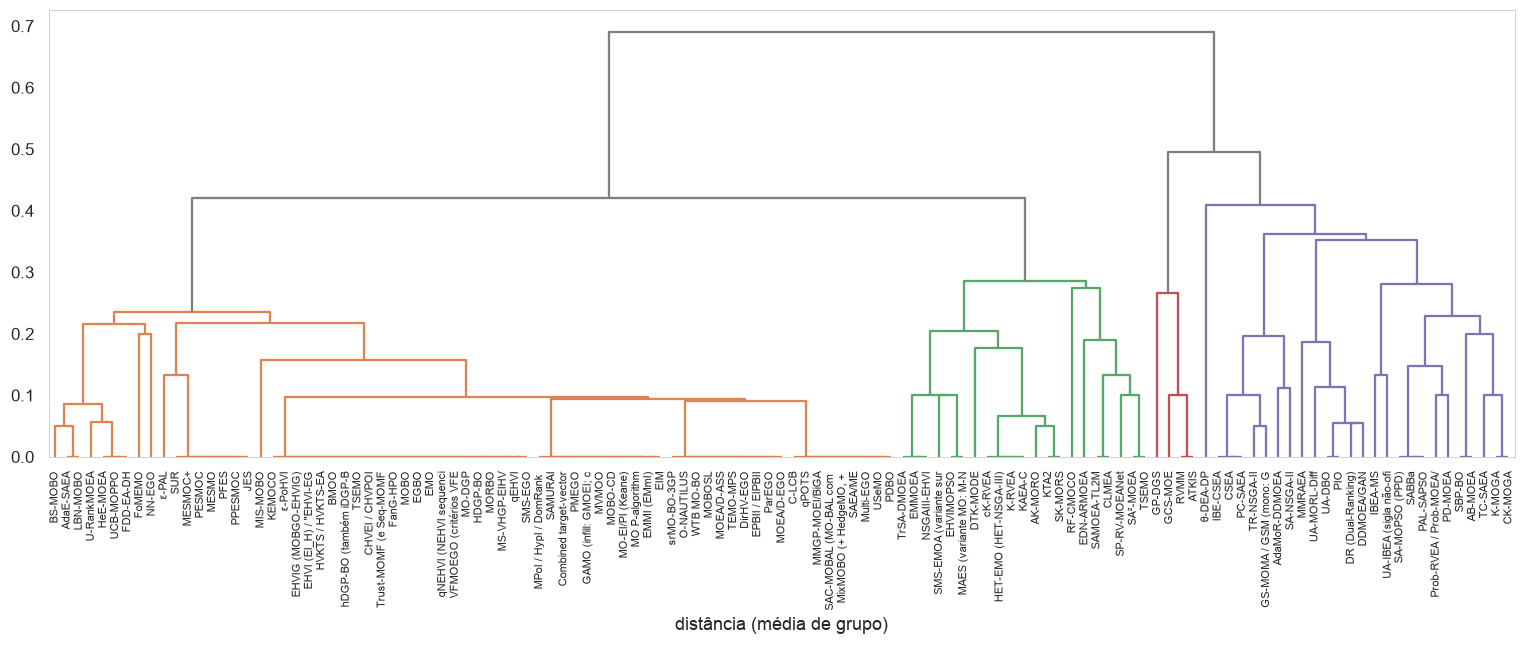

In [22]:
### Dendrograma inteiro (leitura de trabalho; a figura da seção vem depois, com nomes de exibição)
fig, ax = plt.subplots(figsize=(14, 6))
k = 4
dendrogram(Z, labels=dfi.loc[nomeados, 'acronimo'].str[:22].tolist(), orientation='top', leaf_font_size=7, ax=ax,
           color_threshold=(Z[-k, 2] + Z[-k + 1, 2]) / 2, above_threshold_color='grey')
ax.set_xlabel('distância (média de grupo)')
plt.tight_layout(); plt.show()

52 perfis únicos · correlação cofenética: 0.814


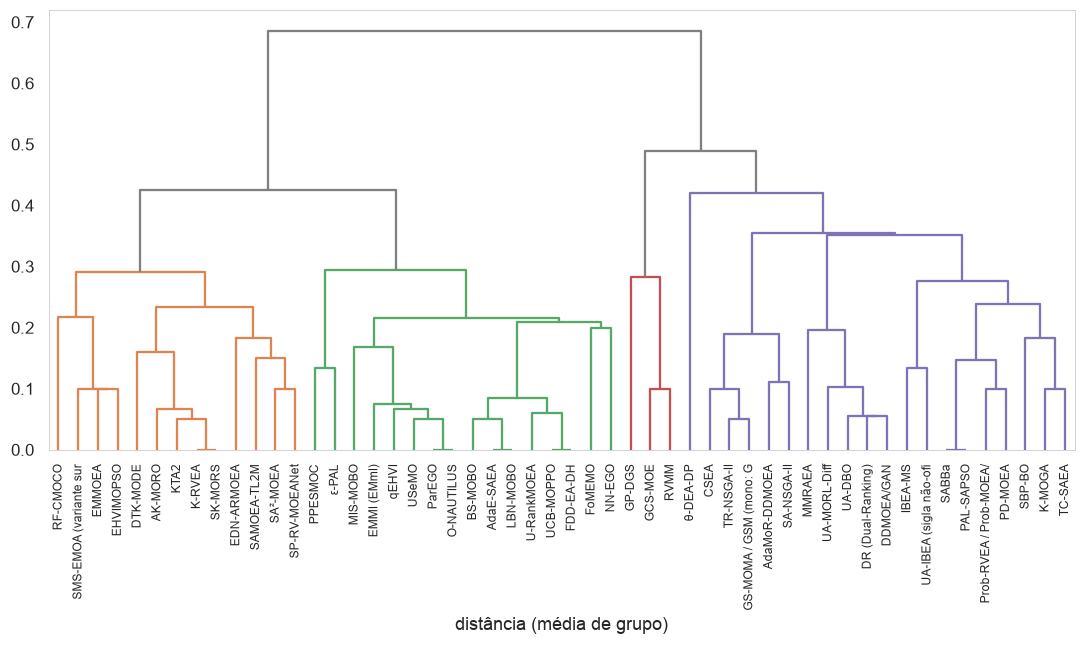

In [23]:
### Dendrograma sobre perfis únicos (um estudo por combinação dos cinco caracteres)
unicos = dfi.loc[nomeados].drop_duplicates(subset=EIXOS).index.tolist()
vu = squareform(df_distancias.loc[unicos, unicos].values, checks=False)
Zu = linkage(vu, method='average')
cofenetica_u, _ = cophenet(Zu, vu)
print(len(unicos), 'perfis únicos · correlação cofenética:', round(cofenetica_u, 3))    # 52 · 0.814

fig, ax = plt.subplots(figsize=(10, 6))
dendrogram(Zu, labels=dfi.loc[unicos, 'acronimo'].str[:22].tolist(), orientation='top', leaf_font_size=8, ax=ax,
           color_threshold=(Zu[-k, 2] + Zu[-k + 1, 2]) / 2, above_threshold_color='grey')
ax.set_xlabel('distância (média de grupo)'); plt.tight_layout(); plt.show()

## [F3] - Agrupamento por partição

In [24]:
### k-medoides (PAM): BUILD (escolha gulosa, determinística) e SWAP (troca enquanto a soma das distâncias cair)
def pam(D, k, candidatos=None):
    """`candidatos` = índices de D que podem ser medoide (None = todos)."""
    n = D.shape[0]
    cand = list(range(n)) if candidatos is None else list(candidatos)
    custo = lambda M: D[:, M].min(axis=1).sum()
    med = [min(cand, key=lambda c: D[:, c].sum())]                # 1º medoide: o candidato mais central
    while len(med) < k:                                            # BUILD: entra quem mais reduz o custo
        dmin = D[:, med].min(axis=1)
        ganho = [(np.maximum(dmin - D[:, c], 0).sum(), -c) for c in cand if c not in med]
        med.append(-max(ganho)[1])
    atual = custo(med)
    while True:                                                    # SWAP: a melhor troca medoide ↔ não-medoide
        melhor = None
        for i, m in enumerate(med):
            for c in cand:
                if c in med: continue
                novo = med[:i] + [c] + med[i + 1:]
                cn = custo(novo)
                if cn < atual - 1e-12 and (melhor is None or cn < melhor[0]):
                    melhor = (cn, novo)
        if melhor is None: break
        atual, med = melhor
    rot = np.argmin(D[:, med], axis=1)
    return rot, med, atual


def ari(r1, r2):
    """Índice de Rand ajustado (Hubert e Arabie, 1985): 1 = mesmas partições, ≈0 = concordância ao acaso."""
    t = pd.crosstab(r1, r2).values
    s_ij = sum(comb(int(x), 2) for x in t.ravel())
    s_a = sum(comb(int(x), 2) for x in t.sum(axis=1)); s_b = sum(comb(int(x), 2) for x in t.sum(axis=0))
    esp = s_a * s_b / comb(int(t.sum()), 2); maxi = (s_a + s_b) / 2
    return 1.0 if maxi == esp else (s_ij - esp) / (maxi - esp)

In [25]:
### Calcula k-medoides (PAM) para k = 1 … 10: uma coluna por k, os medoides e as curvas
completos = [p for p, i in enumerate(nomeados) if dfi.loc[i, EIXOS].notna().all()]     # 112 candidatos a medoide (D3)
df_familias_pam = pd.DataFrame({'id': nomeados})
medoides = {}
linhas = []
for k in range(1, 11):
    rot, med, custo = pam(D, k, completos)
    rot = rotulos_por_tamanho(rot)
    df_familias_pam[f'pam_k{k}'] = rot
    medoides[k] = {int(rot[m]): dfi.at[nomeados[m], 'acronimo'] for m in med}      # família → seu medoide
    tamanhos = df_familias_pam[f'pam_k{k}'].value_counts().tolist()
    linhas.append({'k': k, 'custo': custo,
                   'dist_intra': dist_intra(D, rot),
                   'silhueta': silhueta(D, rot).mean() if k > 1 else np.nan,
                   'ari_vs_hier': ari(rot, df_familias_hier[f'fam_k{k}'].values) if k > 1 else np.nan,
                   'menor_familia': min(tamanhos), 'tamanhos': tamanhos})

# Resumo de metricas por k
dp_curvas_pam = pd.DataFrame(linhas).set_index('k')
dp_curvas_pam

,custo,dist_intra,silhueta,ari_vs_hier,menor_familia,tamanhos
k,,,,,,
1,36.432275,0.416963,NaN,NaN,121,[121]
2,22.120106,0.235129,0.568354,0.573460,38,"[83, 38]"
3,17.829630,0.179347,0.558690,0.552634,20,"[74, 27, 20]"
4,15.496296,0.187937,0.310364,0.600573,20,"[50, 26, 25, 20]"
5,13.628571,0.143994,0.403808,0.585896,8,"[51, 24, 20, 18, 8]"
6,12.428571,0.149936,0.339061,0.333597,8,"[29, 25, 24, 18, 17, 8]"
7,11.228571,0.141693,0.398247,0.301822,8,"[25, 24, 18, 17, 15, 14, 8]"
8,10.238095,0.131741,0.428980,0.287386,8,"[25, 24, 18, 16, 11, 11, 8, 8]"
9,9.271429,0.112117,0.479929,0.305371,4,"[25, 21, 18, 16, 11, 10, 8, 8, 4]"


In [26]:
### Junta ao df3: os 6 de resíduo de função ficam com 0 (família de resíduos)
df4 = df3.merge(df_familias_pam, on='id', how='left')
cols_pam = [c for c in df4.columns if c.startswith('pam_k')]
df4[cols_pam] = df4[cols_pam].fillna(0).astype(int)

print(df4.shape)
df4.head()

(127, 35)


,id,acronimo,funcao,motor,regime,surrogate,medicao,atitude_funcao,objeto_funcao,paradigma_motor,...,pam_k1,pam_k2,pam_k3,pam_k4,pam_k5,pam_k6,pam_k7,pam_k8,pam_k9,pam_k10
0,b1,ParEGO,OV,BO-Decomposição,online,GP,VA,oportunidade,valor,BO,...,1,1,1,1,1,1,6,5,6,6
1,b13,AdaMoR-DDMOEA,AM,EA-Decomposição,offline,NN,EE,ameaça,modelo,EA,...,1,2,2,2,5,6,7,7,7,7
2,b14,SA²-MOEA,OM,EA-Dominância,online,RG,DE,oportunidade,modelo,EA,...,1,2,3,4,3,5,4,8,8,8
3,b15,U-RankMOEA,OV,BO-Especiais,online,GP,DE,oportunidade,valor,BO,...,1,1,1,1,2,3,2,2,2,4
4,b2,MOEA/D-EGO,OV,BO-Decomposição,online,GP,VA,oportunidade,valor,BO,...,1,1,1,1,1,1,6,5,6,6


In [27]:
resumo_particao(df4, 'pam_k3')

,n,tipo,atitude,paradigma,fonte,regime,membros
familia,,,,,,,
1,74,qEHVI,"{'oportunidade': 71, 'ameaça': 3}","{'BO': 70, nan: 3, 'EA': 1}","{'analítica': 64, 'fabricada': 10}",{'online': 74},"ParEGO, U-RankMOEA, MOEA/D-EGO, USeMO, BS-MOBO, qEHVI, SMS-EGO, EMMI (EMmI), MS-VHGP-EIHV, AdaE-SAEA, EPBII / EIPBII, MORBO, PPESMOC, LBN-MOBO, JES, FoMEMO,..."
2,27,K-MOGA,{'ameaça': 27},"{'EA': 24, nan: 2, 'BO': 1}","{'fabricada': 14, 'analítica': 13}","{'online': 15, 'offline': 12}","AdaMoR-DDMOEA, CSEA, Prob-RVEA / Pr, DR (Dual-Ranki, θ-DEA-DP, DDMOEA/GAN, MMRAEA, PC-SAEA, K-MOGA, GP-DGS, IBE-CSEA, PD-MOEA, UA-DBO, SABBa, PAL-SAPSO, UA-..."
3,20,AK-MORO,{'oportunidade': 20},"{'EA': 19, nan: 1}","{'analítica': 13, 'fabricada': 7}","{'online': 19, 'offline': 1}","SA²-MOEA, K-RVEA, KTA2, SP-RV-MOEANet, DTK-MODE, EMMOEA, SAMOEA-TL2M, EHVIMOPSO, AK-MORO, KAEA-C, SK-MORS, EDN-ARMOEA, CLMEA, HET-EMO (HET-N, NSGAIII-EHVI, ..."


In [28]:
resumo_particao(df4, 'pam_k4')

,n,tipo,atitude,paradigma,fonte,regime,membros
familia,,,,,,,
1,50,USeMO,"{'oportunidade': 46, 'ameaça': 4}","{'BO': 47, nan: 3}","{'analítica': 42, 'fabricada': 8}","{'online': 49, 'offline': 1}","ParEGO, U-RankMOEA, MOEA/D-EGO, USeMO, EMMI (EMmI), AdaE-SAEA, EPBII / EIPBII, PPESMOC, LBN-MOBO, JES, FoMEMO, PDBO, UCB-MOPPO, PFES, MESMO, GCS-MOE, Multi-..."
2,26,K-MOGA,{'ameaça': 26},"{'EA': 24, nan: 2}","{'fabricada': 14, 'analítica': 12}","{'online': 15, 'offline': 11}","AdaMoR-DDMOEA, CSEA, Prob-RVEA / Pr, DR (Dual-Ranki, θ-DEA-DP, DDMOEA/GAN, MMRAEA, PC-SAEA, K-MOGA, IBE-CSEA, PD-MOEA, UA-DBO, SABBa, PAL-SAPSO, UA-MORL-Dif..."
3,25,qEHVI,{'oportunidade': 25},"{'BO': 24, 'EA': 1}","{'analítica': 23, 'fabricada': 2}",{'online': 25},"BS-MOBO, qEHVI, SMS-EGO, MS-VHGP-EIHV, MORBO, HDGP-BO, MO-DGP, VFMOEGO (crité, qNEHVI (NEHVI , EMO, EGBO, MOBO, FanG-HPO, Trust-MOMF (e , CHVEI / CHVPOI, TS..."
4,20,AK-MORO,{'oportunidade': 20},"{'EA': 19, nan: 1}","{'analítica': 13, 'fabricada': 7}","{'online': 19, 'offline': 1}","SA²-MOEA, K-RVEA, KTA2, SP-RV-MOEANet, DTK-MODE, EMMOEA, SAMOEA-TL2M, EHVIMOPSO, AK-MORO, KAEA-C, SK-MORS, EDN-ARMOEA, CLMEA, HET-EMO (HET-N, NSGAIII-EHVI, ..."


In [29]:
medoides[4]

{1: 'USeMO', 2: 'K-MOGA', 4: 'AK-MORO', 3: 'qEHVI'}

pam_k4,1,2,3,4,0
fam_k3,,,,,
1,46,0,25,20,0
2,0,26,0,0,0
0,0,0,0,0,6
3,4,0,0,0,0


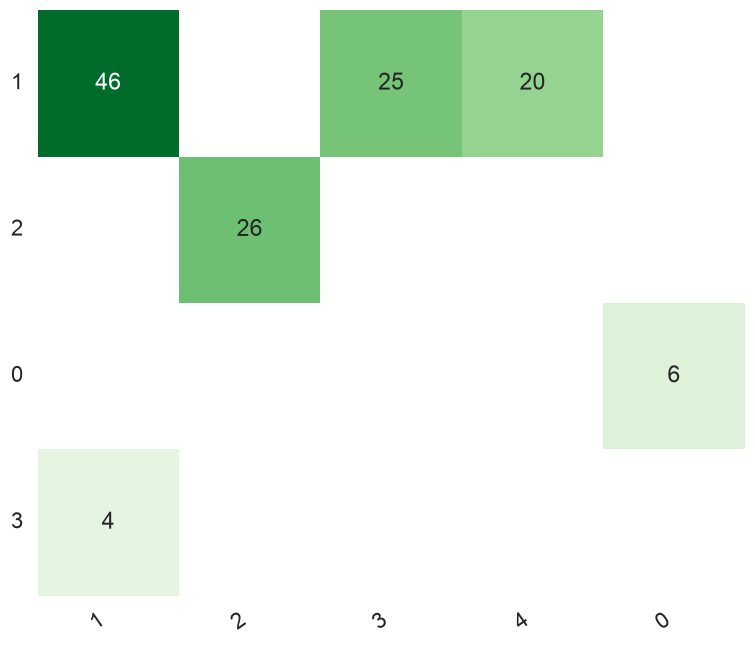

In [30]:
heatmap_2d(df4, 'fam_k3', 'pam_k4')        # onde os dois métodos concordam e discordam

pam_k4,1,2,3,4,0
fam_k4,,,,,
1,46,0,24,0,0
2,0,26,0,0,0
3,0,0,1,20,0
0,0,0,0,0,6
4,4,0,0,0,0


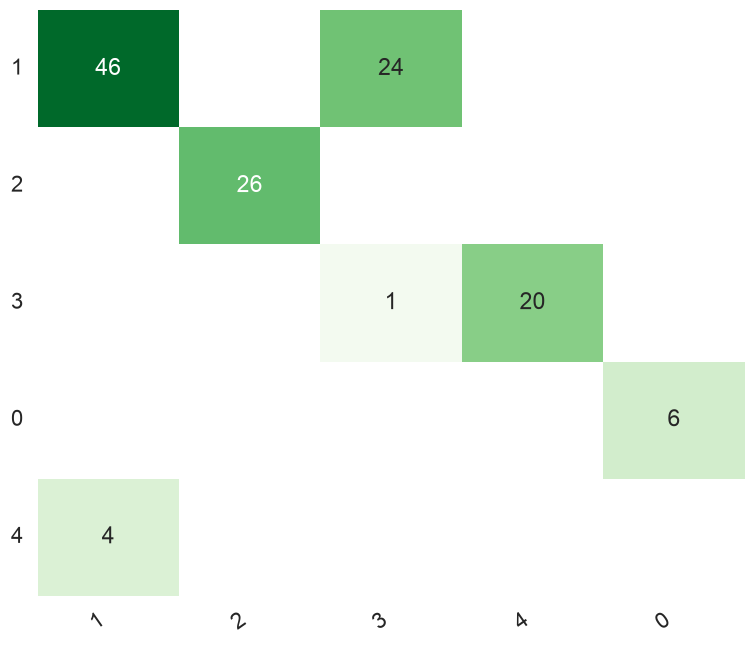

In [31]:
heatmap_2d(df4, 'fam_k4', 'pam_k4')        # onde os dois métodos concordam e discordam

familia_teorica,BO_oportunidade_analítica,EA_ameaça_fabricada,EA_oportunidade_analítica,EA_ameaça_analítica,BO_oportunidade_fabricada,EA_oportunidade_fabricada,BO_ameaça_analítica,residuo
pam_k4,,,,,,,,
1,37,0,0,0,6,0,4,3
2,0,13,0,11,0,0,0,2
3,22,0,1,0,2,0,0,0
4,0,0,12,0,0,7,0,1
0,0,0,0,0,0,0,0,6


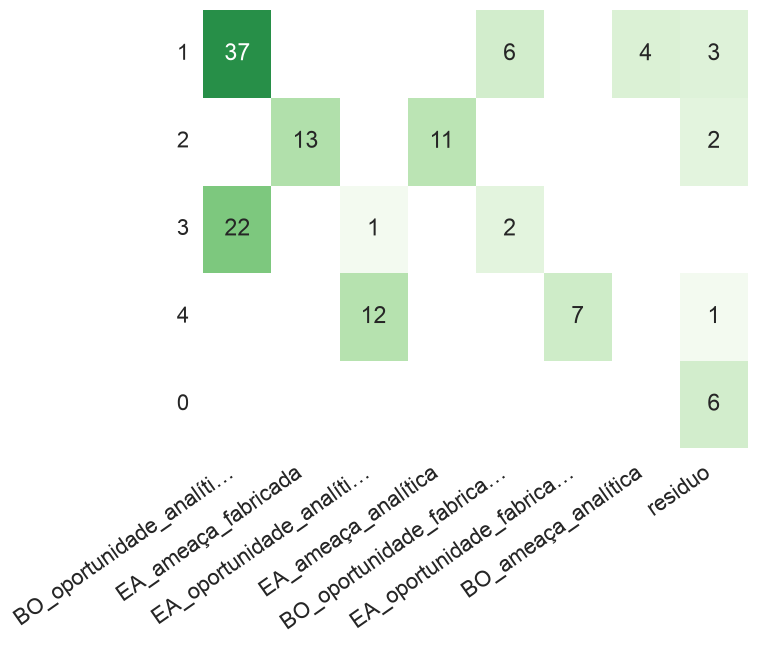

In [32]:
heatmap_2d(df4, "pam_k4", "familia_teorica")

## Análise de resultados

familia_teorica,BO_oportunidade_analítica,EA_ameaça_fabricada,EA_oportunidade_analítica,EA_ameaça_analítica,BO_oportunidade_fabricada,EA_oportunidade_fabricada,BO_ameaça_analítica,residuo
fam_k4,,,,,,,,
1,59,0,0,0,8,0,0,3
2,0,13,0,11,0,0,0,2
3,0,0,13,0,0,7,0,1
0,0,0,0,0,0,0,0,6
4,0,0,0,0,0,0,4,0


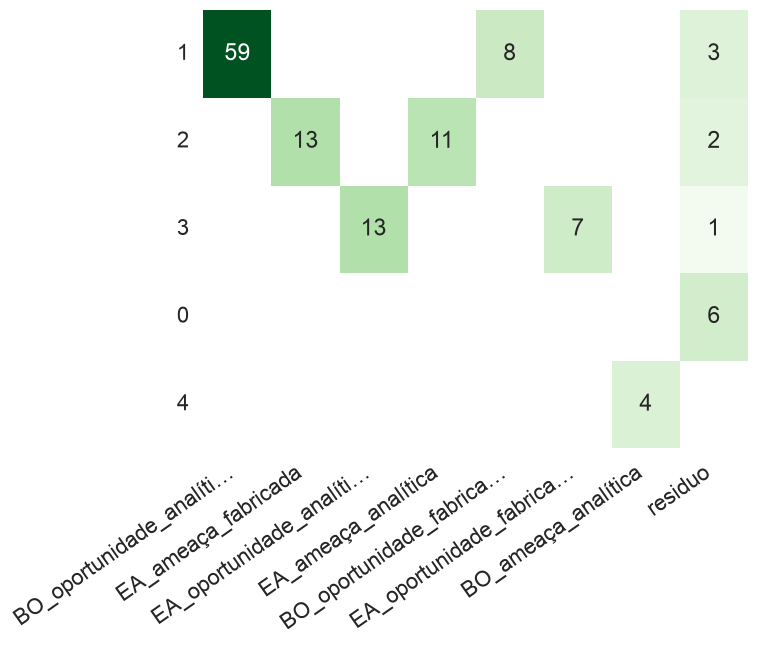

In [33]:
heatmap_2d(df3, "fam_k4", "familia_teorica")

familia_teorica,BO_oportunidade_analítica,EA_ameaça_fabricada,EA_oportunidade_analítica,EA_ameaça_analítica,BO_oportunidade_fabricada,EA_oportunidade_fabricada,BO_ameaça_analítica,residuo
fam_k7,,,,,,,,
1,59,0,0,0,8,0,0,3
2,0,0,13,0,0,7,0,1
3,0,0,0,11,0,0,0,1
4,0,7,0,0,0,0,0,0
5,0,5,0,0,0,0,0,1
0,0,0,0,0,0,0,0,6
6,0,0,0,0,0,0,4,0
7,0,1,0,0,0,0,0,0


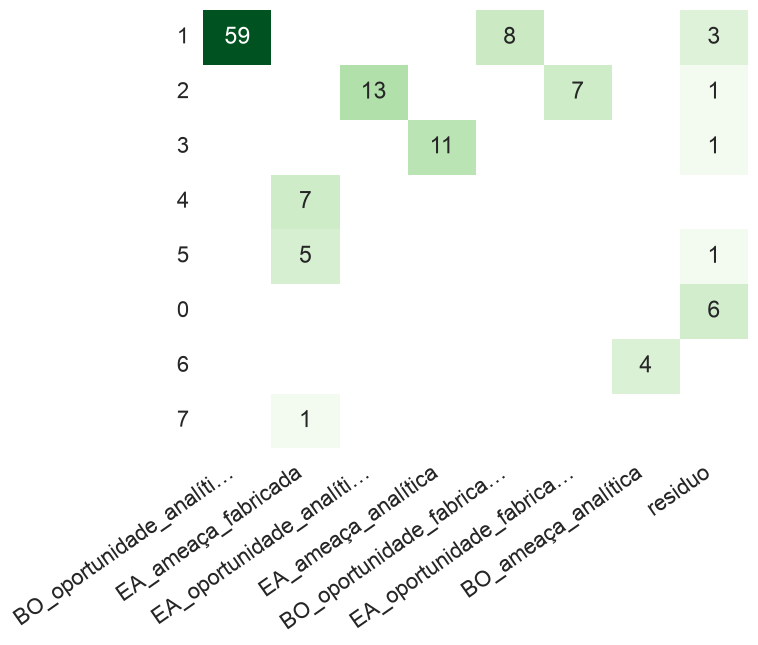

In [34]:
heatmap_2d(df3, "fam_k7", "familia_teorica")

# Arrumar

In [36]:
STOP, THEY DONT LOVE YOU LIKE I LOVE YOU

SyntaxError: invalid syntax (684229173.py, line 1)

In [ ]:
nomeados = [i for i in ids if base[i]['funcao'] != 'Res-fun']     # o conjunto que será agrupado
print(len(nomeados), 'estudos com função nomeada entram no agrupamento')     # esperado: 121
print(df.loc[nomeados, EIXOS].isna().sum().rename('caracteres ausentes'))  # motor 6 · surrogate 1 · medicao 2


In [ ]:



# quadro oficial vigente (CLAUDE.md §9 + erratas 04/08-11 e 06/08-1)
DETECTOR = {
  'motor':     {'EA-Dominância':27, 'BO-Hipervolume':25, 'BO-Especiais':24, 'EA-Decomposição':15,
                'BO-Decomposição':12, 'BO-Melhoria-de-Pareto':12, 'Resíduo':7, 'EA-Indicador':5},
  'surrogate': {'GP':97, 'RG':14, 'NN':11, 'CL':4, 'Res-sur':1},
  'funcao':    {'OV':69, 'OM':15, 'AV':12, 'AM':11, 'AR':7, 'OL':7, 'Res-fun':6},
  'medicao':   {'VA':93, 'DE':15, 'EE':10, 'VN':4, 'DG':3, 'Res-med':2},
  'regime':    {'online':111, 'offline':16},
}
for eixo, esperado in DETECTOR.items():
    obs = dict(Counter(base[i][eixo] for i in ids))
    assert obs == esperado, f'{eixo}: obtido {obs}'
    assert sum(obs.values()) == 127
print('detector OK — a base em disco é a vigente')

# quem tem resíduo em algum eixo (esses precisam da regra de resíduos)
res = {i: [e for e in ('motor','surrogate','funcao','medicao') if base[i][e].startswith('Res')] for i in ids}
res = {i: e for i, e in res.items() if e}
print(len(res), 'estudos com ≥1 resíduo:')          # esperado: 15
for i, e in sorted(res.items()): print(f'  {i:6s} {base[i]["acronimo"][:24]:24s} resíduo em {e}')

In [ ]:


D_EIXO = {'funcao': d_funcao, 'motor': d_motor, 'regime': d_regime, 'surrogate': d_surrogate, 'medicao': d_medicao}

# 1c. As matrizes classe × classe de cada eixo — a árvore do D2 vista como tabela.
ORDEM = {'funcao': ['OV','OM','OL','AV','AM','AR'],
         'motor':  ['EA-Dominância','EA-Decomposição','EA-Indicador','BO-Melhoria-de-Pareto','BO-Decomposição','BO-Hipervolume','BO-Especiais'],
         'regime': ['online','offline'],
         'surrogate': ['GP','RG','NN','CL'],
         'medicao': ['VA','VN','DE','EE','DG']}
MAT = {}
for e, classes in ORDEM.items():
    m = pd.DataFrame([[D_EIXO[e](a, b) for b in classes] for a in classes], index=classes, columns=classes)
    assert np.allclose(m, m.T) and np.allclose(np.diag(m), 0)        # simétrica, diagonal zero
    MAT[e] = m
    print(f'\n{e}:'); print(m.round(3).to_string())

# 1d. Conferências de leitura contra o capítulo
assert d_funcao('OV','AV') == 2/3 and d_funcao('OV','OM') == 1/3 and d_funcao('OV','AM') == 1 and d_funcao('OL','AR') == 1
assert d_motor('BO-Decomposição','EA-Decomposição') == 2/3 and d_motor('BO-Hipervolume','EA-Dominância') == 1
assert d_motor('BO-Especiais','BO-Hipervolume') == 1/3 and all(d_motor('BO-Especiais', m) == 1 for m in ORDEM['motor'] if m.startswith('EA'))
assert d_surrogate('GP','NN') == 0.5 and d_surrogate('GP','CL') == 1 and d_medicao('VA','VN') == 1
print('\nárvores OK')

In [ ]:
# ── Bloco 2 · a distância de Gower entre estudos (D1 + D2 + D3) ──
# Para cada par de estudos: soma ponderada das diferenças eixo a eixo (árvore do D2), dividida pela
# soma dos pesos dos eixos que os DOIS estudos têm (um resíduo é carácter ausente e sai da conta).


def gower(i, j, pesos=PESOS):
    num = den = 0.0
    for e, w in pesos.items():
        a, b = df.at[i, e], df.at[j, e]
        if pd.isna(a) or pd.isna(b):        # carácter ausente em um dos dois → fora da conta (D3)
            continue
        num += w * D_EIXO[e](a, b)
        den += w
    return num / den

n = len(nomeados)
D = np.zeros((n, n))
for p in range(n):
    for q in range(p + 1, n):
        D[p, q] = D[q, p] = gower(nomeados[p], nomeados[q])
D_df = pd.DataFrame(D, index=nomeados, columns=nomeados)
pos = {i: p for p, i in enumerate(nomeados)}

# 2a. Conferência dos custos elementares da tabela do D1, com pares REAIS do corpus.
# Cada caso traz o perfil esperado dos dois estudos (função, motor, regime, surrogate, medição) e o custo;
# o perfil é conferido ANTES do custo, para que a conferência não passe por acaso.
def perfil(i): return tuple(None if pd.isna(x) else x for x in (df.at[i, e] for e in EIXOS))
CASOS = [
  ('b1',   ('OV','BO-Decomposição','online','GP','VA'),  'c262', ('OV','BO-Hipervolume','online','GP','VA'),   0.100, 'ParEGO × qNEHVI: só o princípio do motor (decomposição × hipervolume)'),
  ('pp6',  ('AV','EA-Decomposição','online','GP','VA'),  'c241', ('OV','EA-Decomposição','online','GP','VA'),  0.267, 'AB-MOEA × EMMOEA: o espelho, só a atitude (AV × OV)'),
  ('b1',   ('OV','BO-Decomposição','online','GP','VA'),  'c241', ('OV','EA-Decomposição','online','GP','VA'),  0.200, 'ParEGO × EMMOEA: só o paradigma (BO·decomposição × EA·decomposição)'),
  ('b4',   ('AM','EA-Dominância','online','CL','EE'),    'c250', ('AM','EA-Dominância','online','GP','VA'),    0.200, 'CSEA × K-MOGA: a fonte do σ com classificador (CL·EE × GP·VA)'),
  ('c50',  ('AR','EA-Dominância','offline','GP','VA'),   'c66',  ('AR','EA-Dominância','online','GP','VA'),    0.100, 'PD-MOEA × PAL-SAPSO: só o regime (offline × online)'),
  ('mtm4', ('OV','EA-Dominância','online','GP','VA'),    'e30',  ('OM','EA-Dominância','online','GP','VA'),    0.133, 'MAES × AK-MORO: só o objeto (OV × OM)'),
  ('c1',   ('OV','BO-Hipervolume','online','NN','DE'),   'c262', ('OV','BO-Hipervolume','online','GP','VA'),   0.150, 'BS-MOBO × qNEHVI: a fonte do σ com regressor (NN·DE × GP·VA)'),
  ('c65',  ('AR',None,'online','GP','VA'),               'c66',  ('AR','EA-Dominância','online','GP','VA'),    0.000, 'SABBa × PAL-SAPSO: SABBa tem resíduo de motor; no resto são iguais → 0 (D3)'),
  ('c65',  ('AR',None,'online','GP','VA'),               'b5',   ('AR','EA-Decomposição','offline','GP','VA'), 0.143, 'SABBa × Prob-RVEA: motor ausente, só o regime difere → 0,10 / 0,70'),
]
for a, pa, b, pb, esperado, texto in CASOS:
    assert perfil(a) == pa, f'{a}: perfil na base {perfil(a)} ≠ esperado {pa}'
    assert perfil(b) == pb, f'{b}: perfil na base {perfil(b)} ≠ esperado {pb}'
    assert abs(gower(a, b) - esperado) < 5e-4, f'{texto}: obtido {gower(a, b):.3f}'
    print(f'  {gower(a, b):.3f}  {texto}')
print('custos elementares OK')

# 2b. Propriedades da matriz
assert np.allclose(D, D.T) and np.allclose(np.diag(D), 0) and D.max() <= 1 + 1e-9
valores = np.unique(np.round(D[np.triu_indices(n, 1)], 6))
print(f'\n{n}×{n} distâncias · {len(valores)} valores distintos · máxima {D.max():.3f} · média {D[np.triu_indices(n,1)].mean():.3f}')
zeros = int((D[np.triu_indices(n, 1)] == 0).sum())
print(f'pares com distância 0 (perfis idênticos nos caracteres presentes): {zeros}')

# 2c. Os vizinhos mais próximos de alguns algoritmos do plantel — leitura de sanidade
def vizinhos(i, k=5):
    s = D_df.loc[i].drop(i).sort_values()
    return ', '.join(f'{df.at[j,"acronimo"][:14]} ({d:.2f})' for j, d in s.head(k).items())
for i in ['b1', 'b3', 'b4', 'c141', 'e74', 'c122', 'e8']:
    print(f'{df.at[i,"acronimo"][:14]:14s} → {vizinhos(i)}')

In [ ]:
# 3b. UPGMA — a média de grupo sobre D. Z tem n-1 linhas, uma por junção: quem juntou com quem,
#     a que altura (a distância média entre os dois grupos) e quantos membros o grupo novo tem.
Dc = squareform(D, checks=False)                  # a metade superior de D como vetor: o formato que o scipy pede
Z = linkage(Dc, method='average')
cofenetica, _ = cophenet(Z, Dc)
print(f'correlação cofenética do dendrograma: {cofenetica:.3f}   (pré-registro: ≥ 0,75)')




# 3e. As curvas para k = 1 … 10
PART, MED, linhas = {}, {}, []
for k in range(1, 11):
    ru, limpo = cortar(Z, k)
    rp, med, custo_pam = pam(D, k)
    PART[('upgma', k)], PART[('pam', k)], MED[k] = ru, rp, med
    tam_u = sorted((int(x) for x in np.bincount(ru)), reverse=True); tam_p = sorted((int(x) for x in np.bincount(rp)), reverse=True)
    linhas.append({'k': k, 'corte limpo': limpo,
                   'intra UPGMA': dist_intra(D, ru), 'sil UPGMA': silhueta(D, ru).mean() if k > 1 else np.nan, 'menor fam UPGMA': min(tam_u),
                   'intra PAM': dist_intra(D, rp),   'sil PAM':   silhueta(D, rp).mean() if k > 1 else np.nan, 'menor fam PAM': min(tam_p),
                   'ARI UPGMA×PAM': ari(ru, rp) if k > 1 else np.nan,
                   'tamanhos UPGMA': tam_u, 'tamanhos PAM': tam_p})
curvas = pd.DataFrame(linhas).set_index('k')
pd.set_option('display.width', 200)
print(curvas.drop(columns=['tamanhos UPGMA', 'tamanhos PAM']).round(3).to_string())
print('\ntamanhos das famílias por k:')
for k in curvas.index: print(f'  k={k:2d}  UPGMA {curvas.at[k, "tamanhos UPGMA"]}   PAM {curvas.at[k, "tamanhos PAM"]}')

# 3f. O dendrograma inteiro (leitura de trabalho; a figura da seção vem depois, com nomes de exibição)
fig, ax = plt.subplots(figsize=(9, 30))
dendrogram(Z, labels=[df.at[i, 'acronimo'][:22] for i in nomeados], orientation='right', leaf_font_size=7, ax=ax)
ax.set_xlabel('distância (média de grupo)')
plt.tight_layout(); plt.show()

### Heatmaps 2D

In [ ]:
heatmap_2d("surrogate_classe", "macro_motor")                    # reproduz a figura8
heatmap_2d("medicao_classe", "surrogate_classe")                 # reproduz a figura15
heatmap_2d("motor_classe", "regime", vmax=None, rot_x=0, figsize=(5,5))
heatmap_2d("funcao_classe", "medicao_classe", salvar_em="cruz.pdf")